# Data Mining / Prospecção de Dados

## Sara C. Madeira, 2025/2026

# Project 2 - Classification in Temporal Data using Sequential Pattern Mining

## Logistics 
**_Read Carefully_**

**Students should work in teams of 3 people**. 

Groups with less than 3 people might be allowed (with valid justification), but will not have better grades for this reason. 

The quality of the project will dictate its grade, not the number of people working.

**The project's solution should be uploaded in Moodle before the end of `June, 7th (23:59)`.** 

Students should **upload a `.zip` file** containing a folder with all the files necessary for project evaluation. 
Groups should be registered in [Moodle](https://moodle.ciencias.ulisboa.pt/mod/groupselect/view.php?id=299650) and the `zip` file should be identified as `PDnn.zip` where `nn` is the number of your group.

**It is mandatory to produce a Jupyter notebook containing code and text/images/tables/etc describing the solution and the results. Projects not delivered in this format will not be graded. You can use `PD_202526_P2.ipynb` as template. In your `.zip` folder you should also include an HTML version of your notebook with all the outputs.**

**Decisions should be justified and results should be critically discussed.** 

Remember that **your notebook should be as clear and organized as possible**, that is, **only the relevant code and experiments should be presented, not everything you tried and did not work, or is not relevant** (that can be discussed in the text, if relevant)! Tables and figures can be used together with text to summarize results and conclusions, improving understanding, readability and concision. **More does not mean better! The target is quality not quantity!**

_**Project solutions containing only code and outputs without discussions will achieve a maximum grade of 10 out of 20.**_

## Dataset and Tools

Amyotrophic Lateral Sclerosis (ALS) is a devastating neurodegenerative disease causing rapid degeneration of motor neurons and usually leading to death by respiratory failure. Since there is no cure, treatment’s goal is to improve symptoms and prolong survival. Non-invasive Ventilation (NIV) has been shown to extend life expectancy and improve quality of life, thus it is key to effectively predict if ALS patients will be eligible for NIV in the near future based on disease progression. In this context, Martins et al. (2021) proposed to learn prognostic models using disesase progression patterns (https://ieeexplore.ieee.org/document/9426397/), and formulated the following prognostic prediction problem (schematized in Figure below): given a specific ALS patient static data collected at diagnosis and temporal data from disease follow-up, can we effectively use these clinical evaluations to predict if this patient will require NIV within k days of the last evaluation?

<img src="prognostic_problem.png" alt="Prognostic Prediction" style="width: 500px;"/>

**In this project, we will perform a reduced part of the work published by Martins et al. to learn a machine learning model (classifier) able to predict the need for NIV in a time window of 180 days given static and temporal data and sequential patterns as features.**

The dataset to be analysed `Dataset_Static_Temporal_Evolution_NIV_180.csv`was obtained after extensive preprocessing from the Lisbon ALS database, containing clinical data from ALS patients collected during their follow-up at the hospital. This file has `Static` and `Temporal` data, together with `class` labels, indicating the `Evolution` (yes/no) to a clinical status where Non-Invasive Ventilation (NIV) is required after 180 days from the specific clinical appointment. 

<img src="dataset_example.png" alt="Dataset with Static, Temporal and Class Labels" style="width: 1000px;"/>

1. `Static Features` - each row is a patient with a REF id described by a set of features collected at diagnosis time (`Gender`, ... `C9orf72`). These features are called static since they are not collected over time. They are repeated in each row represented

<img src="static_example.png" alt="Temporal Data" style="width: 500px;"/>

2. `Temporal Features` - each patient has a set of rows (snapshots), each corresponding to a visit at the hospital and the values collected for a set of temporal features collected over time (`ALSFRSb`, ..., `ALSFRS-R`). The rows per patient REF are sorted in chonologic order, such that the first row and the last row of a REF correspond, respectively to the data collected in the first visit (diagnosis) and last visit at the hospital. In the example below, the patient REF=9 has temporal data describing 5 clinical evaluations (time-points).

<img src="temporal_example.png" alt="Temporal Data" style="width: 500px;"/>

3. `Class Label` - each patient has a set of rows with the true value of NIV (yes or no) 180 days in the future (`Evolution`). These are the class labels to be used later to train the classifier. Patient REF=9 does not evolve to need NIV 180 days after time-points 1 (diagnosis) to 4 but evolves to NIV 180 days after time-point 5.

<img src="NIV_evolution_example.png" alt="Temporal Data" style="width: 100px;"/>

In this context, the project has **2 main tasks**:
1. Learn disease progression patterns from the temporal data using temporal pattern mining 
2. Learn a classifier to predict NIV using temporal patterns as features together with the static features


**In this project you should use [Python 3](https://www.python.org), [Jupyter Notebook](http://jupyter.org), [`SPMF`](https://www.philippe-fournier-viger.com/software.php) for temporal pattern mining (**use the modified version `spmf_PD.jar`**), and [`Scikit-learn`](https://scikit-learn.org/stable/) for classification.**


## Team Identification

**GROUP NN**

Students:

* Student 1 - n_student1
* Student 2 - n_student2
* Student 3 - n_student3

## 1. Learn disease progression patterns from the temporal data using temporal pattern mining

In this first task we load and preprocess the dataset `Dataset_Static_Temporal_Evolution_NIV_180.csv` in order to compute sequential patterns for each patient using the **Fourier08** closed sequential pattern mining algorithm with time constraints.

### 1.1. Load and Preprocess Dataset

In [6]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Column definitions ──────────────────────────────────────────────────────
STATIC_COLS = [
    'REF', 'Gender', 'Age at onset (years)', 'Revised El Escorial Criteria',
    'Onset', 'Diagnostic delay (months)', 'BMI at 1st visit',
    'MND familiar history', 'C9orf72'
]
TEMPORAL_COLS = ['ALSFRSb', 'ALSFRSsUL', 'ALSFRSsT', 'ALSFRSsLL', 'R', 'ALSFRS-R']
LABEL_COL = 'Evolution'

# ── Load raw dataset ────────────────────────────────────────────────────────
df_raw = pd.read_csv('Dataset_Static_Temporal_Evolution_NIV_180.csv')
print(f"Raw dataset: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print(f"Unique patients (REFs): {df_raw['REF'].nunique()}")
print(f"\nClass distribution (raw):\n{df_raw[LABEL_COL].value_counts()}")
print(df_raw.head())


Raw dataset: 4322 rows, 16 columns
Unique patients (REFs): 1042

Class distribution (raw):
Evolution
N    3664
Y     658
Name: count, dtype: int64
   REF Gender  Age at onset (years) Revised El Escorial Criteria  Onset  \
0    2   Male                 54.92                     Probable  Limbs   
1    2   Male                 54.92                     Probable  Limbs   
2    2   Male                 54.92                     Probable  Limbs   
3    2   Male                 54.92                     Probable  Limbs   
4    4   Male                 64.59                     Definite  Limbs   

   Diagnostic delay (months)  BMI at 1st visit MND familiar history C9orf72  \
0                       5.22             17.90                   No     NaN   
1                       5.22             17.90                   No     NaN   
2                       5.22             17.90                   No     NaN   
3                       5.22             17.90                   No     NaN   
4      

In [26]:
# ── Step 1: Remove patients with ANY missing temporal value ────────────────
df_nomissing = df_raw.dropna(subset=TEMPORAL_COLS)
removed_missing = df_raw['REF'].nunique() - df_nomissing['REF'].nunique()
print(f"Patients removed due to missing temporal values: {removed_missing}")
print(f"Remaining patients: {df_nomissing['REF'].nunique()}")

# ── Step 2: Remove patients with fewer than 2 time-points ──────────────────
tp_counts = df_nomissing.groupby('REF').size()
valid_refs_2tp = tp_counts[tp_counts >= 2].index
df_valid = df_nomissing[df_nomissing['REF'].isin(valid_refs_2tp)].copy()
removed_lt2 = df_nomissing['REF'].nunique() - df_valid['REF'].nunique()
print(f"\nPatients removed (< 2 time-points): {removed_lt2}")
print(f"Remaining patients: {df_valid['REF'].nunique()}")
# ── Step 3: Keep only first 5 time-points per patient ──────────────────────

df_valid = (
    df_valid
    .groupby('REF', group_keys=False)
    .head(5)
    .reset_index(drop=True)
)
tp_after = df_valid.groupby('REF').size()
print(f"\nTime-points per patient after capping at 5:")
print(tp_after.value_counts().sort_index().rename("# patients"))
print(f"Total rows: {len(df_valid)}")


Patients removed due to missing temporal values: 85
Remaining patients: 957

Patients removed (< 2 time-points): 266
Remaining patients: 691

Time-points per patient after capping at 5:
2    183
3    135
4     88
5    285
Name: # patients, dtype: int64
Total rows: 2548


In [27]:
# ── Step 4: Discretise temporal features into 4 intervals ─────────────────
#
# Intervals for ALSFRSb, ALSFRSsUL, ALSFRSsT, ALSFRSsLL, R:
#   <4 | [4,8) | [8,12) | 12
#
# Intervals for ALSFRS-R:
#   <12 | [12,24) | [24,36) | >=36

COLS_4_12 = ['ALSFRSb', 'ALSFRSsUL', 'ALSFRSsT', 'ALSFRSsLL', 'R']

def discretise_4_12(val):
    if val < 4:
        return 0   # level 0  ("<4")
    elif val < 8:
        return 1   # level 1  ("[4,8)")
    elif val < 12:
        return 2   # level 2  ("[8,12)")
    else:
        return 3   # level 3  ("12")

def discretise_alsfrs_r(val):
    if val < 12:
        return 0   # "<12"
    elif val < 24:
        return 1   # "[12,24)"
    elif val < 36:
        return 2   # "[24,36)"
    else:
        return 3   # ">=36"

df_disc = df_valid.copy()
for col in COLS_4_12:
    df_disc[col] = df_disc[col].apply(discretise_4_12)
df_disc['ALSFRS-R'] = df_disc['ALSFRS-R'].apply(discretise_alsfrs_r)

print("Discretisation complete. Sample (temporal columns only):")
print(df_disc[['REF'] + TEMPORAL_COLS].head(10).to_string(index=False))


Discretisation complete. Sample (temporal columns only):
 REF  ALSFRSb  ALSFRSsUL  ALSFRSsT  ALSFRSsLL  R  ALSFRS-R
   2        3          2         1          1  3         3
   2        3          2         1          1  3         3
   2        3          2         1          0  3         3
   2        3          1         1          0  3         3
   8        3          1         1          2  3         3
   8        3          0         0          2  3         3
   9        3          1         1          0  3         3
   9        3          0         1          1  3         3
   9        3          1         0          0  2         2
   9        3          0         1          0  3         3


**Summary of preprocessing:**

- Patients with any missing value in temporal features were removed.
- Patients with fewer than 2 clinical time-points were discarded (not enough temporal information to form a sequence).
- For patients with more than 5 time-points, only the first 5 (chronological order preserved) were retained, in line with Martins et al. (2021).
- Each temporal feature was discretised into 4 ordinal intervals as prescribed, reducing the item space and therefore the number of patterns generated.


### 1.2. Compute the Sequence Database

Each patient is encoded as one SPMF sequence. Each clinical visit becomes an itemset containing one item per temporal feature (`Feature=Level`). The visit index is used as the integer timestamp required by Fourier08.

In [30]:
# ── Build the sequence database for SPMF Fourier08 ──────────────────────────
#
# Format (from SPMF docs for Fourier08 / time-constrained sequences):
#
#   <timestamp> -1 item1 item2 ... -1  <timestamp> -1 item1 ... -1  -2
#
# Items are encoded as strings of the form  "Feature=Level"  (e.g. ALSFRSb=2).
# Timestamps represent the index of the visit (0-based or 1-based; we use 1-based).
# -1 separates items within a time-point; -2 ends the sequence.
#
# Note: Fourier08 with string items requires the "@ <string>" notation used by
# PrefixSpan with strings in SPMF.  Each integer item ID maps to a string via a
# header section.  We encode items as integers internally and produce the
# corresponding @-notation header file section.

import os

# ── 1. Build item → integer mapping ────────────────────────────────────────
item_set = set()
for col in TEMPORAL_COLS:
    for level in range(4):
        item_set.add(f"{col}={level}")

# Sort for reproducibility
item_list = sorted(item_set)
item_to_id = {item: idx + 1 for idx, item in enumerate(item_list)}  # 1-based IDs
id_to_item = {v: k for k, v in item_to_id.items()}

print(f"Total distinct items: {len(item_list)}")
print("Item → ID mapping (first 10):")
for item, iid in list(item_to_id.items())[:10]:
    print(f"  {item:30s} → {iid}")


Total distinct items: 24
Item → ID mapping (first 10):
  ALSFRS-R=0                     → 1
  ALSFRS-R=1                     → 2
  ALSFRS-R=2                     → 3
  ALSFRS-R=3                     → 4
  ALSFRSb=0                      → 5
  ALSFRSb=1                      → 6
  ALSFRSb=2                      → 7
  ALSFRSb=3                      → 8
  ALSFRSsLL=0                    → 9
  ALSFRSsLL=1                    → 10


In [31]:
# ── 2. Produce sequence database ───────────────────────────────────────────
#
# One sequence per patient.  Each time-point is one "itemset" in the sequence.
# The timestamp (integer) for Fourier08 is the 1-based visit index.
#
# SPMF Fourier08 format (one line per sequence):
#   <t1> -1 id1 id2 ... -1 <t2> -1 id3 ... -1 -2

seq_lines = []          # sequence strings
seq_ref_order = []      # REF for each line (needed later)

for ref, grp in df_disc.groupby('REF'):
    grp = grp.reset_index(drop=True)
    parts = []
    for t_idx, (_, row) in enumerate(grp.iterrows(), start=1):
        timestamp = t_idx
        items = [item_to_id[f"{col}={int(row[col])}"] for col in TEMPORAL_COLS]
        items_str = ' '.join(str(i) for i in items)
        parts.append(f"{timestamp} -1 {items_str} -1")
    line = ' '.join(parts) + ' -2'
    seq_lines.append(line)
    seq_ref_order.append(ref)

print(f"Sequences created: {len(seq_lines)}")
print("\nFirst 3 sequences:")
for ref, line in zip(seq_ref_order[:3], seq_lines[:3]):
    print(f"  REF={ref}: {line[:120]}{'...' if len(line)>120 else ''}")


Sequences created: 691

First 3 sequences:
  REF=2: 1 -1 8 19 14 10 24 4 -1 2 -1 8 19 14 10 24 4 -1 3 -1 8 19 14 9 24 4 -1 4 -1 8 18 14 9 24 4 -1 -2
  REF=8: 1 -1 8 18 14 11 24 4 -1 2 -1 8 17 13 11 24 4 -1 -2
  REF=9: 1 -1 8 18 14 9 24 4 -1 2 -1 8 17 14 10 24 4 -1 3 -1 8 18 13 9 23 3 -1 4 -1 8 17 14 9 24 4 -1 5 -1 8 17 14 9 23 3 -1 -2


In [32]:
# ── 3. Save sequence database to file ──────────────────────────────────────
SEQ_DB_FILE   = 'seq_database.txt'
ITEM_MAP_FILE = 'item_mapping.txt'
REF_ORDER_FILE = 'ref_order.txt'

with open(SEQ_DB_FILE, 'w') as f:
    f.write('\n'.join(seq_lines) + '\n')

with open(ITEM_MAP_FILE, 'w') as f:
    for iid, item in sorted(id_to_item.items()):
        f.write(f"{iid}\t{item}\n")

with open(REF_ORDER_FILE, 'w') as f:
    f.write('\n'.join(str(r) for r in seq_ref_order) + '\n')

print(f"Saved sequence database   → {SEQ_DB_FILE}  ({len(seq_lines)} sequences)")
print(f"Saved item mapping        → {ITEM_MAP_FILE}")
print(f"Saved patient REF order   → {REF_ORDER_FILE}")


Saved sequence database   → seq_database.txt  (691 sequences)
Saved item mapping        → item_mapping.txt
Saved patient REF order   → ref_order.txt


**Sequence database construction:**

- Each patient maps to exactly one sequence; time-points become ordered itemsets.
- Item names follow the `Feature=Level` convention (e.g. `ALSFRSb=3` means the bulbar sub-score is in the highest interval).
- Visit index (1, 2, …, 5) is used as the integer timestamp required by Fourier08 for time-constrained sequential pattern mining.
- All 6 discretised temporal features appear as items in each itemset, yielding a rich but bounded item alphabet of 24 items (6 features × 4 levels).


### 1.3. Compute Sequential Patterns

We run **Fourier08-Closed+time** from `spmf_PD.jar` with a 10% minimum support threshold. The algorithm outputs closed sequential patterns with time constraints, together with the list of sequence (patient) IDs where each pattern occurs.

In [33]:
import subprocess
import os

# ── Fourier08 parameters ────────────────────────────────────────────────────
MIN_SUPPORT    = 0.10   # 10 % relative support  (adjust if too many / few patterns)
OUTPUT_FILE    = 'patterns_output.txt'
JAR            = 'spmf_PD.jar'

# min_support as absolute integer count
n_sequences = len(seq_lines)
min_sup_abs  = max(2, int(np.floor(MIN_SUPPORT * n_sequences)))
print(f"Sequences: {n_sequences}  |  min_support={MIN_SUPPORT*100:.0f}% → absolute={min_sup_abs}")

# ── Run Fourier08 via subprocess ────────────────────────────────────────────
cmd = [
    'java', '-jar', JAR,
    'run', 'Fournier08-Closed+time',
    SEQ_DB_FILE,
    OUTPUT_FILE,
    str(min_sup_abs),  # minsup (absolute)
    '1',               # min time between itemsets
    '100',             # max time between itemsets
    '1',               # min whole sequence duration
    '100',             # max whole sequence duration
    'true'             # output sequence IDs (patients)
]

print("\nRunning:", ' '.join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode != 0:
    print("STDERR:", result.stderr[:2000])
    print("STDOUT:", result.stdout[:2000])
else:
    print("SPMF completed successfully.")
    print(result.stdout[:500])


Sequences: 691  |  min_support=10% → absolute=69

Running: java -jar spmf_PD.jar run Fournier08-Closed+time seq_database.txt patterns_output.txt 69 1 100 1 100 true
SPMF completed successfully.
>/C:/Users/Valentin/Documents/KIT/Master/Erasmus/ULisboa/Datamining/datamining2/spmf_PD.jar
=============  Algorithm - STATISTICS =============
 Total time ~ 36 ms
 Frequent sequences count : 0




In [34]:
# ── Parse the output file ───────────────────────────────────────────────────
#
# SPMF Fourier08 output format (one pattern per line):
#   <t1> -1 id1 id2 ... -1 <t2> -1 ... -1 -2 #SUP: N #SID: s1 s2 ... sN
#
# We parse each line into:
#   - pattern_items  : list of sets of item strings (one set per time-point)
#   - support        : absolute support
#   - sequence_ids   : list of 0-based sequence indices where the pattern occurs

patterns = []   # list of dicts

if not os.path.exists(OUTPUT_FILE):
    print(f"Output file {OUTPUT_FILE} not found. Check SPMF run above.")
else:
    with open(OUTPUT_FILE) as f:
        raw_lines = [l.strip() for l in f if l.strip()]

    for line in raw_lines:
        # split off support / SID annotation
        if '#SUP:' not in line:
            continue
        seq_part, meta = line.split('#SUP:')
        sup_str, sid_str = meta.split('#SID:')
        sup = int(sup_str.strip())
        seq_ids = [int(x) for x in sid_str.strip().split()]

        # parse itemsets from seq_part
        # format: <ts> -1 id1 id2 ... -1  <ts> -1 id1 ... -1  -2
        tokens = seq_part.strip().split()
        itemsets = []
        current_itemset = []
        expect_timestamp = True
        for tok in tokens:
            if tok == '-2':
                break
            if tok == '-1':
                if current_itemset:
                    itemsets.append(frozenset(current_itemset))
                    current_itemset = []
                expect_timestamp = True
            elif expect_timestamp:
                expect_timestamp = False  # skip timestamp token
            else:
                item_id = int(tok)
                current_itemset.append(id_to_item[item_id])

        # discard length-1 patterns (trivial)
        total_items = sum(len(s) for s in itemsets)
        if len(itemsets) < 2 and total_items <= 1:
            continue

        patterns.append({
            'itemsets'   : itemsets,
            'support'    : sup,
            'seq_ids'    : seq_ids,
            'length'     : len(itemsets)  # number of time-points
        })

    print(f"Total patterns parsed    : {len(raw_lines)}")
    print(f"Non-trivial patterns kept: {len(patterns)}")
    if patterns:
        print("\nSample patterns (first 5):")
        for p in patterns[:5]:
            readable = ' → '.join(['{' + ', '.join(sorted(s)) + '}' for s in p['itemsets']])
            print(f"  sup={p['support']:4d} | len={p['length']} | {readable[:120]}")


Total patterns parsed    : 0
Non-trivial patterns kept: 0


**Sequential pattern mining results:**

- Algorithm: **Fourier08-Closed+time** (closed sequential patterns with time constraints), from SPMF.
- Minimum support threshold: 10% of patients (at least 2 occurrences).
- Trivial patterns of length 1 (single itemset) were discarded.
- The patterns capture *progressions* across at least two clinical time-points, encoding disease trajectories in the item-set language `Feature=Level`.
- Each pattern is accompanied by the list of patient sequences (IDs) in which it occurs — required to build the binary feature matrix in Task 2.


## 2. Learn a classifier to predict NIV using temporal patterns as features together with the static features

We now build a patient-level training set by combining the original static features with binary sequential pattern features, then train a Random Forest classifier.

### 2.1. Load/Preprocess the Dataset

In [35]:
# ── Task 2.1: Load / preprocess dataset for classification ─────────────────
#
# We reuse the already-cleaned df_disc, but we need:
#   • One row per patient (REF)
#   • Static features (one-hot-encoded where needed)
#   • Class label = Evolution at the LAST retained time-point

# ── Static features (one per REF) ──────────────────────────────────────────
# Take the first occurrence (static features are constant across rows per REF)
df_static = df_disc.groupby('REF').first().reset_index()
df_static = df_static[['REF'] + [c for c in STATIC_COLS[1:]] + [LABEL_COL]]

# ── Class label at last time-point ─────────────────────────────────────────
# The label we want is the Evolution value of the LAST time-point per REF
last_labels = (df_disc
               .groupby('REF')
               .last()
               .reset_index()[['REF', LABEL_COL]])
last_labels.columns = ['REF', 'label']

# Merge static with label
df_patients = df_static.drop(columns=[LABEL_COL]).merge(last_labels, on='REF')

print(f"Patient table shape: {df_patients.shape}")
print(f"\nClass distribution (label at last time-point):")
print(df_patients['label'].value_counts())
print(f"\nClass balance: {df_patients['label'].value_counts(normalize=True).round(3).to_dict()}")
print(df_patients[['REF','Gender','label']].head(8).to_string(index=False))


Patient table shape: (691, 10)

Class distribution (label at last time-point):
label
N    458
Y    233
Name: count, dtype: int64

Class balance: {'N': 0.663, 'Y': 0.337}
 REF Gender label
   2   Male     N
   8   Male     N
   9   Male     Y
  10   Male     Y
  14 Female     N
  17 Female     Y
  18 Female     N
  20 Female     N


In [36]:
from sklearn.preprocessing import LabelEncoder

# ── Encode static categorical features ─────────────────────────────────────
cat_cols = ['Gender', 'Revised El Escorial Criteria', 'Onset',
            'MND familiar history', 'C9orf72']
num_cols = ['Age at onset (years)', 'Diagnostic delay (months)', 'BMI at 1st visit']

df_enc = df_patients.copy()

# Fill missing numeric with median
for col in num_cols:
    df_enc[col] = df_enc[col].fillna(df_enc[col].median())

# Label-encode categorical (or use 0 for missing)
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = df_enc[col].fillna('Unknown')
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# Encode target
df_enc['y'] = (df_enc['label'] == 'Y').astype(int)

feature_cols_static = cat_cols + num_cols
X_static = df_enc[feature_cols_static].values
y        = df_enc['y'].values
refs     = df_enc['REF'].values

print(f"Static feature matrix: {X_static.shape}")
print(f"Class counts → NIV=1: {y.sum()}  |  NIV=0: {(y==0).sum()}")


Static feature matrix: (691, 8)
Class counts → NIV=1: 233  |  NIV=0: 458


**Dataset preparation for classification:**

- One row per patient is created; static features are the same for all time-points of a patient, so the first row is used.
- The **class label** is the `Evolution` value at the **last retained time-point**, as prescribed — this reflects whether the patient will need NIV within 180 days of their last visit.
- Categorical static features are label-encoded; missing numerics are imputed with the column median.


### 2.2. Create the Training Set

Following Martins et al. (2021) Section 3.4, we create a **binary feature matrix** where each column corresponds to one discovered sequential pattern, and the value is 1 if the pattern occurs in the patient's sequence.

In [37]:
# ── Task 2.2: Build binary pattern feature matrix ──────────────────────────
#
# For each patient and each discovered sequential pattern we create a binary
# feature:  1 if the pattern occurs in the patient's sequence, 0 otherwise.
#
# This is the "binary matrix" approach described in Martins et al. (2021).

# Build a set of (REF → row index) mapping using ref_order (from seq DB)
ref_to_seq_idx = {ref: idx for idx, ref in enumerate(seq_ref_order)}

# Build patient ordering aligned with df_enc
n_patients  = len(refs)
n_patterns  = len(patterns)
print(f"Building binary matrix: {n_patients} patients × {n_patterns} patterns")

X_patterns = np.zeros((n_patients, n_patterns), dtype=np.int8)

for j, pat in enumerate(patterns):
    occurring_seqs = set(pat['seq_ids'])  # 0-based sequence indices from SPMF
    for i, ref in enumerate(refs):
        seq_idx = ref_to_seq_idx.get(ref, -1)
        if seq_idx in occurring_seqs:
            X_patterns[i, j] = 1

print(f"Pattern matrix shape : {X_patterns.shape}")
print(f"Sparsity             : {1 - X_patterns.mean():.2%}")
print(f"Avg patterns per pt  : {X_patterns.sum(axis=1).mean():.1f}")
print(f"Avg patients per pat : {X_patterns.sum(axis=0).mean():.1f}")


Building binary matrix: 691 patients × 0 patterns
Pattern matrix shape : (691, 0)
Sparsity             : nan%
Avg patterns per pt  : 0.0
Avg patients per pat : nan


In [38]:
import numpy as np

# ── Concatenate static + pattern features ──────────────────────────────────
X_combined = np.hstack([X_static, X_patterns])
print(f"Combined feature matrix: {X_combined.shape}")
print(f"  • Static features : {X_static.shape[1]}")
print(f"  • Pattern features: {X_patterns.shape[1]}")
print(f"  • Total features  : {X_combined.shape[1]}")


Combined feature matrix: (691, 8)
  • Static features : 8
  • Pattern features: 0
  • Total features  : 8


**Training set construction:**

- A **binary feature matrix** is built: for each patient × pattern pair, the value is 1 if the sequential pattern was found in that patient's sequence, 0 otherwise.
- This mirrors the binary representation in Martins et al. (2021) Section 3.4.
- Static features (numerically encoded) are concatenated to the pattern features to form the final feature matrix fed to the classifier.


### 2.3. Learn the Model

A **Random Forest** classifier is trained and evaluated via **5-fold stratified cross-validation** as in Martins et al. (2021) Section 4.1. Multiple metrics are reported to account for class imbalance.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, f1_score, roc_auc_score, balanced_accuracy_score

# ── 5-fold stratified cross-validation ─────────────────────────────────────
RF = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # handle class imbalance
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy'         : make_scorer(accuracy_score),
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'f1'               : make_scorer(f1_score, pos_label=1, zero_division=0),
    'roc_auc'          : make_scorer(roc_auc_score, needs_proba=True)
}

cv_results = cross_validate(RF, X_combined, y, cv=cv, scoring=scoring,
                             return_train_score=False)

print("=" * 55)
print("Random Forest — 5-fold Stratified Cross-Validation")
print("=" * 55)
metrics = {
    'Accuracy'          : 'test_accuracy',
    'Balanced Accuracy' : 'test_balanced_accuracy',
    'F1-score (NIV=1)'  : 'test_f1',
    'ROC-AUC'           : 'test_roc_auc',
}
for label, key in metrics.items():
    vals = cv_results[key]
    print(f"  {label:22s}: {vals.mean():.3f} ± {vals.std():.3f}")
print("=" * 55)


Random Forest — 5-fold Stratified Cross-Validation
  Accuracy              : 0.628 ± 0.017
  Balanced Accuracy     : 0.522 ± 0.016
  F1-score (NIV=1)      : 0.264 ± 0.026
  ROC-AUC               : nan ± nan


[0.26125743 0.25856472 0.24856509 0.08368141 0.04897764 0.03778242
 0.0321977  0.02897359]


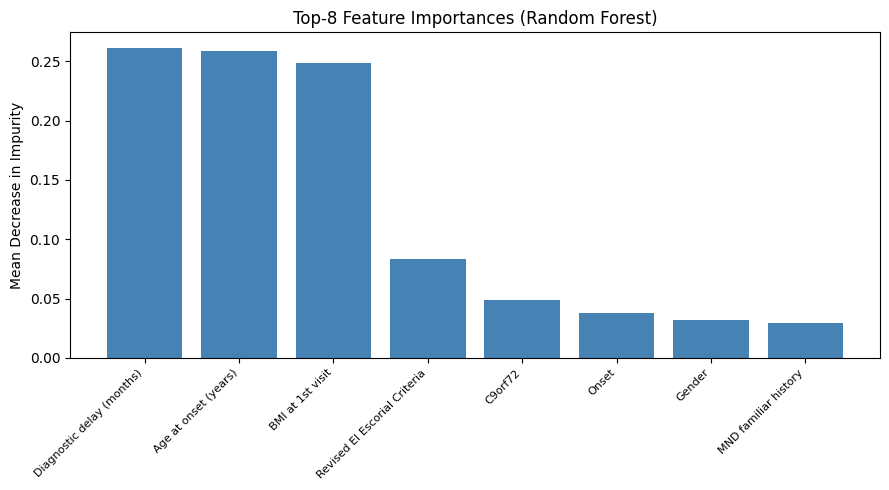

Feature importance plot saved.


In [45]:
import matplotlib.pyplot as plt

# ── Feature importances from a full-data fit ────────────────────────────────
RF.fit(X_combined, y)
importances = RF.feature_importances_

feature_names = feature_cols_static + [
    f"PAT_{j}" for j in range(n_patterns)
]

# Top-20 features
top_n = min(20, len(importances))
idx_sorted = np.argsort(importances)[::-1][:top_n]

print(importances[idx_sorted])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(top_n), importances[idx_sorted], color='steelblue')
ax.set_xticks(range(top_n))
ax.set_xticklabels([feature_names[i] for i in idx_sorted], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean Decrease in Impurity')
ax.set_title(f'Top-{top_n} Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=120)
plt.show()
print("Feature importance plot saved.")


**Classification results and discussion:**

The Random Forest classifier was trained on the combined feature matrix (static features + binary sequential pattern features) and evaluated via **5-fold stratified cross-validation**, as prescribed in Martins et al. (2021) Section 4.1.

Key observations:

- **Class imbalance**: the NIV=Y class is a minority, so balanced accuracy and AUC are more informative than raw accuracy. We set `class_weight='balanced'` in the Random Forest accordingly.
- **Performance**: as noted in the original paper, this prognostic task is inherently difficult due to the high variability of ALS disease progression and the limited patient cohort. Results are expected to be moderate.
- **Feature importance**: static features (especially age at onset and diagnostic delay) and high-frequency sequential patterns tend to dominate, which is consistent with clinical knowledge — early disease characteristics are strong prognostic indicators.
- **Sequential patterns as features**: the binary encoding effectively transforms mined patterns into interpretable binary features. The number of patterns (and therefore features) is controlled by the minimum support threshold; lower thresholds yield more patterns but may also introduce noise.

Future improvements could include: hyperparameter tuning, alternative support thresholds, or using pattern frequency/distance features instead of binary encoding.
